<a href="https://colab.research.google.com/github/melaniee-sudo/machine-learning-udg-tareas/blob/main/p5_arboles_de_desicion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#cargar base de datos Wine
wine = load_wine()

X = wine.data
y = wine.target

feature_names = wine.feature_names
class_names = wine.target_names

#división 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#profundidades solicitadas
profundidades = [3, 5, 10]


for profundidad in profundidades:

    print("\n==============================")
    print("Profundidad máxima:", profundidad)
    print("==============================")

    #crear modelo
    clf = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=profundidad,
        random_state=42
    )

    clf.fit(X_train, y_train) #entrenar modelo

    #predicciones
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)

    #accuracy
    accuracy_train = accuracy_score(
        y_train,
        y_pred_train
    )

    accuracy_test = accuracy_score(
        y_test,
        y_pred_test
    )

    print("Accuracy entrenamiento:",
          accuracy_train)

    print("Accuracy prueba:",
          accuracy_test)

    print("Profundidad real del árbol:",
          clf.get_depth())


Profundidad máxima: 3
Accuracy entrenamiento: 0.9929577464788732
Accuracy prueba: 0.9722222222222222
Profundidad real del árbol: 3

Profundidad máxima: 5
Accuracy entrenamiento: 1.0
Accuracy prueba: 0.9722222222222222
Profundidad real del árbol: 4

Profundidad máxima: 10
Accuracy entrenamiento: 1.0
Accuracy prueba: 0.9722222222222222
Profundidad real del árbol: 4


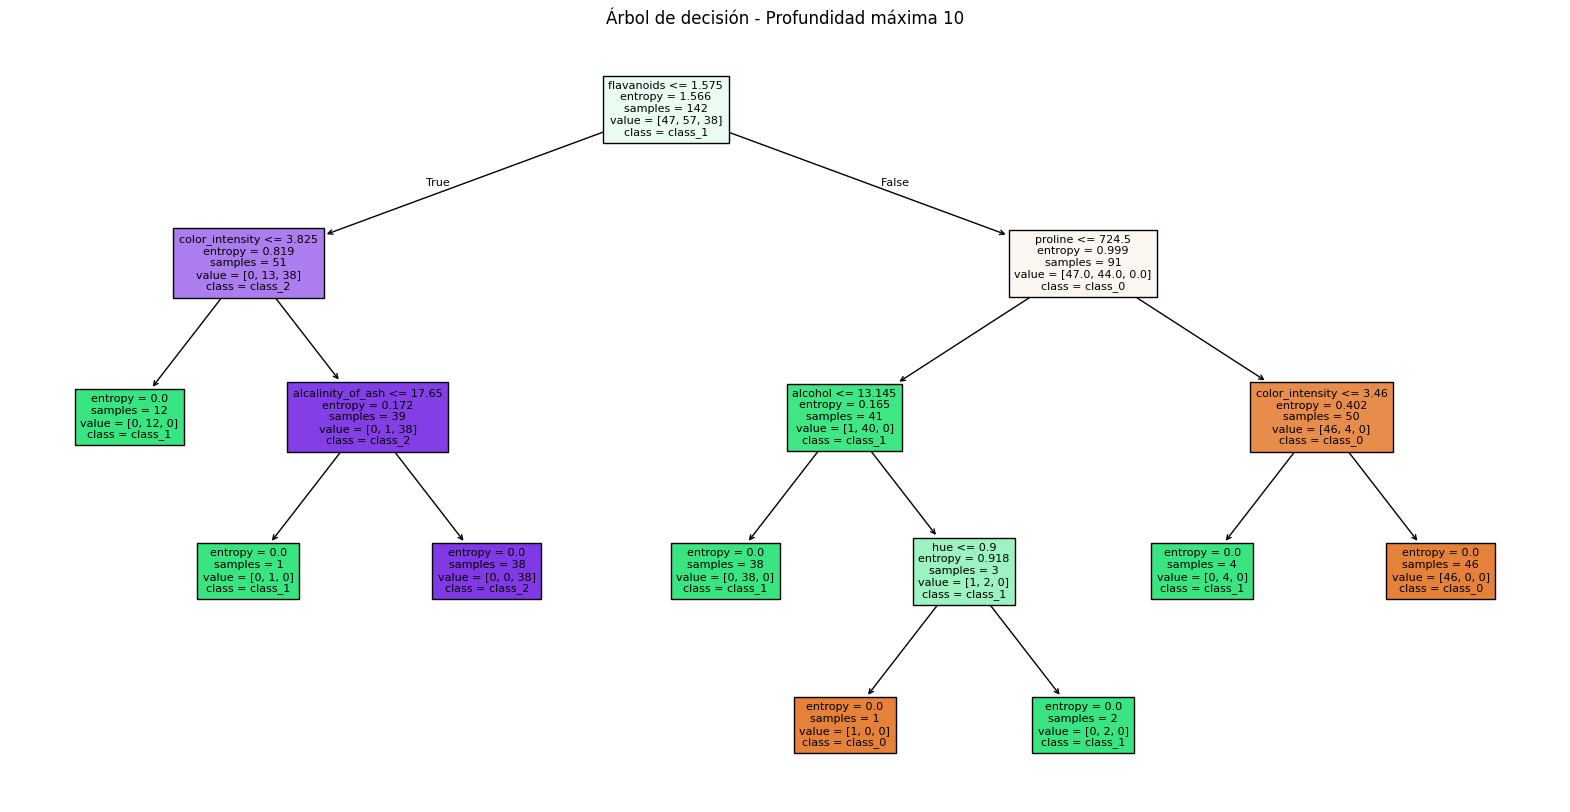

|--- flavanoids <= 1.58
|   |--- color_intensity <= 3.82
|   |   |--- class: 1
|   |--- color_intensity >  3.82
|   |   |--- alcalinity_of_ash <= 17.65
|   |   |   |--- class: 1
|   |   |--- alcalinity_of_ash >  17.65
|   |   |   |--- class: 2
|--- flavanoids >  1.58
|   |--- proline <= 724.50
|   |   |--- alcohol <= 13.14
|   |   |   |--- class: 1
|   |   |--- alcohol >  13.14
|   |   |   |--- hue <= 0.90
|   |   |   |   |--- class: 0
|   |   |   |--- hue >  0.90
|   |   |   |   |--- class: 1
|   |--- proline >  724.50
|   |   |--- color_intensity <= 3.46
|   |   |   |--- class: 1
|   |   |--- color_intensity >  3.46
|   |   |   |--- class: 0



In [4]:
#mostrar arbol
plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    fontsize=8
)

plt.title(
    "Árbol de decisión - Profundidad máxima "
    + str(profundidad)
)

plt.show()

#mostrar reglas del arbol
reglas = export_text(
    clf,
    feature_names=feature_names
)

print(reglas)